In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("AmesHousing.csv")

# Display first 10 rows
print(df.head(10))

   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   
5      6  527105030           60        RL          78.0      9978   Pave   
6      7  527127150          120        RL          41.0      4920   Pave   
7      8  527145080          120        RL          43.0      5005   Pave   
8      9  527146030          120        RL          39.0      5389   Pave   
9     10  527162130           60        RL          60.0      7500   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN  

In [2]:
# Check for missing values
missing_counts = df.isnull().sum()
missing_columns = missing_counts[missing_counts > 0].sort_values(ascending=False)
print(missing_columns)

Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


Mean SalePrice: 180796.06


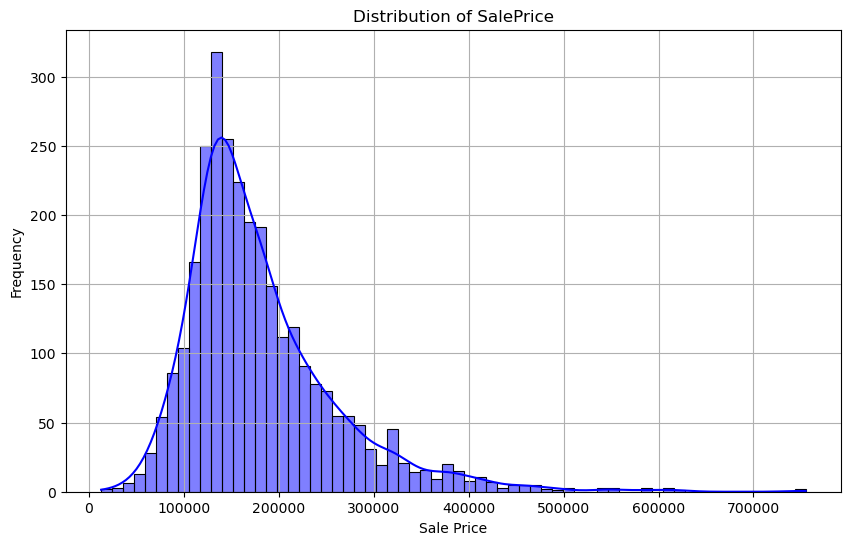

In [3]:
# Mean of SalePrice
mean_price = df['SalePrice'].mean()
print(f"Mean SalePrice: {mean_price:.2f}")

# Histogram of SalePrice
plt.figure(figsize=(10, 6))
sns.histplot(df['SalePrice'], kde=True, color='blue')
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [13]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(exclude=[np.number]).columns

# Impute numerical columns with mean
for col in num_cols:
    if df[col].isnull().sum() > 0:
        # Assign the result back to the column to persist the changes
        df[col] = df[col].fillna(df[col].mean())

# Impute categorical columns with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        # Assign the result back to the column to persist the changes
        # Use .iloc[0] or [0] to get the first value of the mode series
        df[col] = df[col].fillna(df[col].mode()[0])

print("Imputation complete.")

Imputation complete.


In [14]:
# One-hot encoding
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=False)

print("Shape after encoding:", df_encoded.shape)


Shape after encoding: (2930, 306)


In [19]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop("SalePrice", axis=1)
y = df_encoded["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [26]:
X_train.shape

(2344, 305)

In [27]:
X_test.shape

(586, 305)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# Create Linear Regression model
baseline_model = LinearRegression()

# Train the model on training data
baseline_model.fit(X_train_scaled, y_train)

# Predict SalePrice on test data
y_pred_baseline = baseline_model.predict(X_test_scaled)

# Calculate RMSE
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))

print("Baseline Linear Regression RMSE:", baseline_rmse)

Baseline Linear Regression RMSE: 29222.053141651806


In [60]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential()

# Input layer + First hidden layer
model.add(Dense(64, activation='relu', input_dim=X_train_scaled.shape[1]))

# Second hidden layer
model.add(Dense(32, activation='relu'))

# Output layer for regression
model.add(Dense(1))

# Display model summary
model.summary()

C:\Users\Hamed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │        19,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,697 (84.75 KB)

 Trainable params: 21,697 (84.75 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
# Compile model
model.compile(optimizer='adam', loss='mse')

# Train model and save history
history = model.fit(
X_train_scaled, y_train,
validation_split=0.2,
epochs=50,
batch_size=32,
verbose=1
)

Epoch 1/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 37743222784.0000 - val_loss: 38207053824.0000
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37731942400.0000 - val_loss: 38180323328.0000
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37668847616.0000 - val_loss: 38068543488.0000
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37475217408.0000 - val_loss: 37781315584.0000
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37062680576.0000 - val_loss: 37238489088.0000
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36359180288.0000 - val_loss: 36382568448.0000
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 35316580352.0000 - val_loss: 35169890304.0000
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33916184576.0000 - val_loss: 33610088448.0000
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32148801536.0000 - val_loss: 31654412288.0000
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 29981

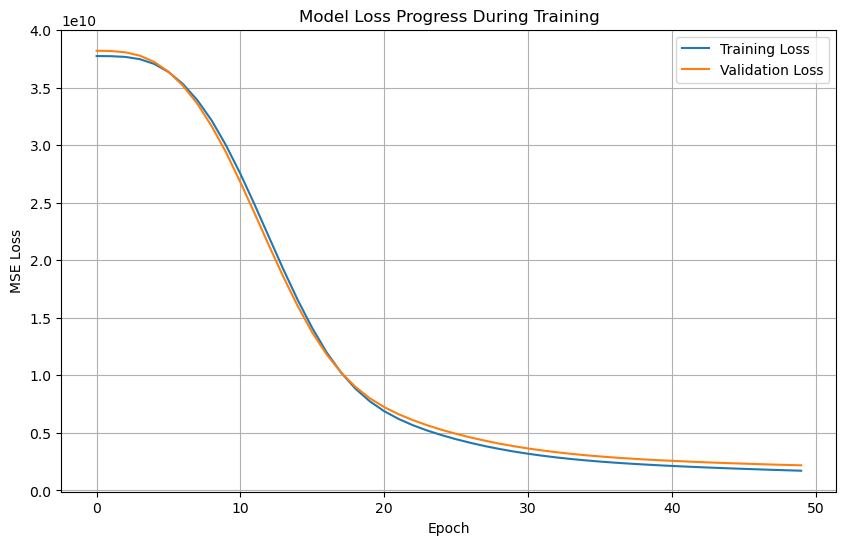

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress During Training')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
from sklearn.metrics import mean_squared_error
import numpy as np

# MLP Prediction
y_pred_mlp = model.predict(X_test_scaled)
mlp_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp))

print(f"Linear Regression RMSE: {baseline_rmse}")
print(f"MLP Regressor RMSE: {mlp_rmse}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Linear Regression RMSE: 29222.053141651806
MLP Regressor RMSE: 45467.277728054054


In [66]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

activations = ['relu', 'tanh', 'sigmoid']
activation_results = {}
activation_histories = {}

for act in activations:
    print(f"Training with activation: {act}")
    
    model = Sequential([
    Dense(64, activation=act, input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation=act),
    Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
    )
    
    val_mse = history.history['val_loss'][-1]
    val_rmse = np.sqrt(val_mse)
    
    activation_results[act] = val_rmse
    activation_histories[act] = history
    
    print(f"{act} Validation RMSE: {val_rmse:.4f}")

Training with activation: relu
Epoch 1/50


C:\Users\Hamed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 37741785088.0000 - val_loss: 38202986496.0000
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37717938176.0000 - val_loss: 38150541312.0000
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37610160128.0000 - val_loss: 37972213760.0000
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37331017728.0000 - val_loss: 37583159296.0000
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36802224128.0000 - val_loss: 36913274880.0000
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 35940118528.0000 - val_loss: 35877756928.0000
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 34679017472.0000 - val_loss: 34421039104.0000
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33012494336.0000 - val_loss: 32549898240.0000
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30926442496.0000 - val_loss: 30330013696.0000
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 28482582528.0000

C:\Users\Hamed\AppData\Local\Temp\ipykernel_22580\3053075908.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(activation_results.keys()), y=list(activation_results.values()),


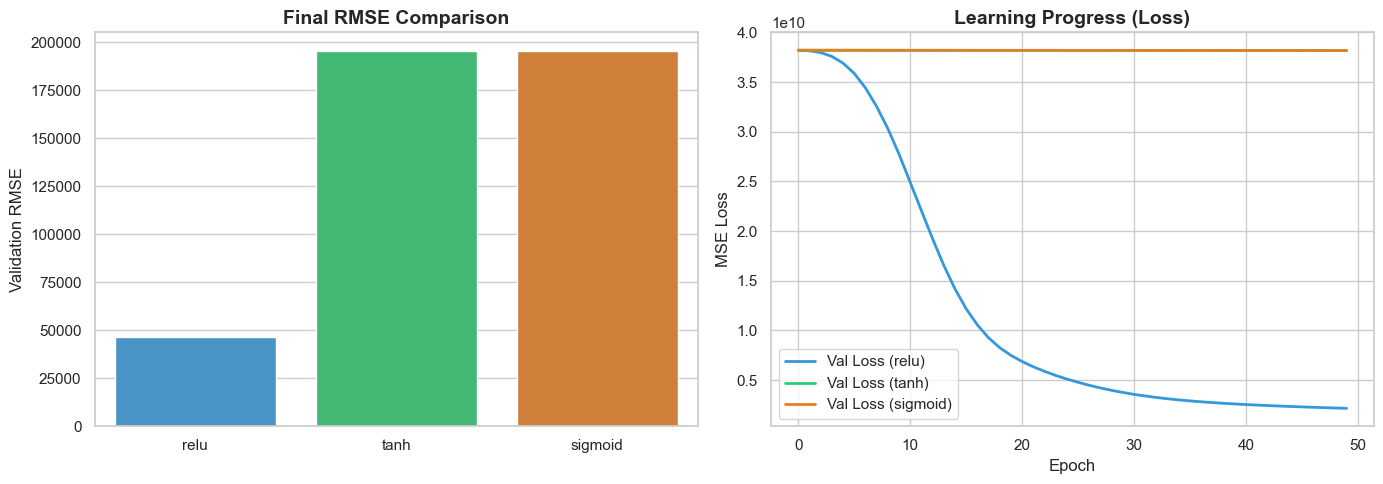

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

colors = ["#3498db", "#2ecc71", "#e67e22"]
sns.barplot(x=list(activation_results.keys()), y=list(activation_results.values()), 
            palette=colors, ax=ax[0])
ax[0].set_title('Final RMSE Comparison', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Validation RMSE')


for act, color in zip(activations, colors):
    ax[1].plot(activation_histories[act].history['val_loss'], 
               label=f'Val Loss ({act})', color=color, linewidth=2)

ax[1].set_title('Learning Progress (Loss)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('MSE Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


In [69]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

learning_rates = [0.01, 0.001, 0.0001]
lr_results = {}
lr_histories = {}

for lr in learning_rates:
    print(f"Training with learning rate: {lr}")
    
    model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1)
    ])
    
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    
    history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
    )
    
    val_mse = history.history['val_loss'][-1]
    val_rmse = np.sqrt(val_mse)
    
    lr_results[lr] = val_rmse
    lr_histories[lr] = history
    
    print(f"Learning rate {lr} Validation RMSE: {val_rmse:.4f}")

Training with learning rate: 0.01
Epoch 1/50


C:\Users\Hamed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 37192101888.0000 - val_loss: 35437780992.0000
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25254365184.0000 - val_loss: 12231719936.0000
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5227294208.0000 - val_loss: 3438564608.0000
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2666637824.0000 - val_loss: 2589273344.0000
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2114136448.0000 - val_loss: 2177166592.0000
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1789861120.0000 - val_loss: 1954795648.0000
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1569306496.0000 - val_loss: 1798963456.0000
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1400174464.0000 - val_loss: 1680986112.0000
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1260083968.0000 - val_loss: 1590281600.0000
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1147225856.0000 - val_loss: 15

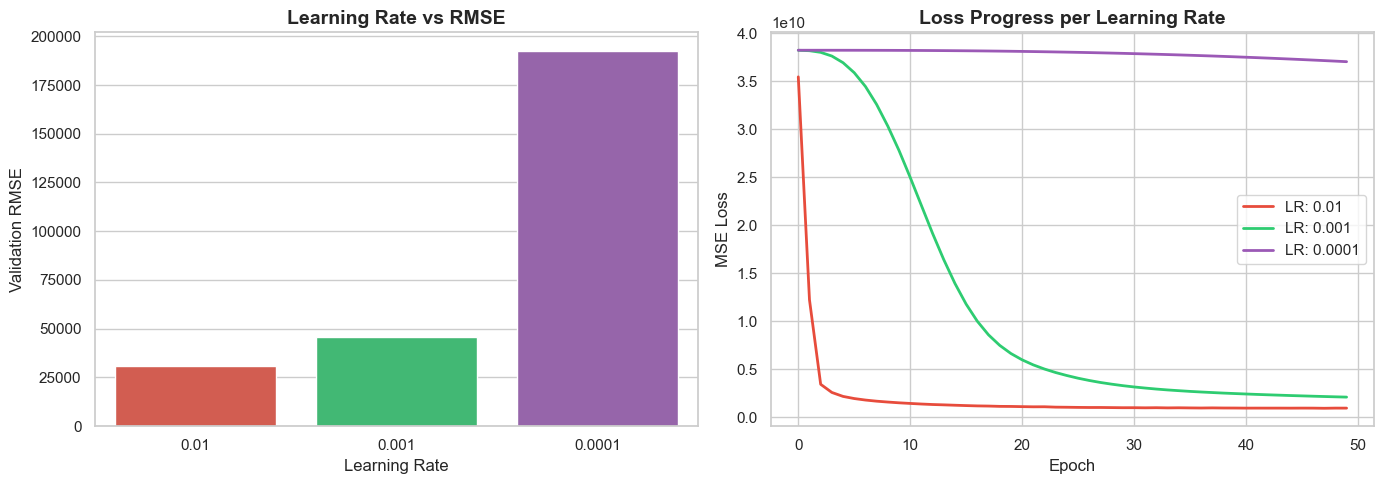

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# تنظیم ظاهر کلی
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# تبدیل نرخ‌های یادگیری به متن برای نمایش بهتر در نمودار
lr_labels = [str(lr) for lr in learning_rates]

# ۱. نمودار میله‌ای مقایسه RMSE برای Learning Rates
colors = ["#e74c3c", "#2ecc71", "#9b59b6"] # قرمز، سبز، بنفش
sns.barplot(x=lr_labels, y=list(lr_results.values()), 
            hue=lr_labels, palette=colors, legend=False, ax=ax[0])

ax[0].set_title('Learning Rate vs RMSE', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Validation RMSE')
ax[0].set_xlabel('Learning Rate')

# ۲. نمودار روند یادگیری (Loss) برای هر نرخ یادگیری
for lr, color in zip(learning_rates, colors):
    ax[1].plot(lr_histories[lr].history['val_loss'], 
               label=f'LR: {lr}', color=color, linewidth=2)

ax[1].set_title('Loss Progress per Learning Rate', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('MSE Loss')
ax[1].legend()

plt.tight_layout()
plt.show()


In [76]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# تعریف معماری‌های مختلف
architectures = {
    "1_hidden_layer_64": [64],
    "3_hidden_layers_128_64_32": [128, 64, 32]
}

arch_results = {}
arch_histories = {}

for arch_name, layers in architectures.items():
    print(f"Training architecture: {arch_name}")
    
    # ساخت مدل به صورت پویا بر اساس لیست لایه‌ها
    model = Sequential()
    
    # لایه اول (باید ورودی را مشخص کنیم)
    model.add(Dense(layers[0], activation='relu', input_shape=(X_train_scaled.shape[1],)))
    
    # اضافه کردن سایر لایه‌های پنهان (اگر وجود داشته باشند)
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
    
    # لایه خروجی برای رگرسیون
    model.add(Dense(1))
    
    # کامپایل مدل
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # آموزش مدل
    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        verbose=1
    )
    
    # استخراج خطا و محاسبه RMSE
    val_mse = history.history['val_loss'][-1]
    val_rmse = np.sqrt(val_mse)
    
    arch_results[arch_name] = val_rmse
    arch_histories[arch_name] = history
    
    print(f"{arch_name} Validation RMSE: {val_rmse:.4f}")
    print("-" * 30)


Training architecture: 1_hidden_layer_64
Epoch 1/50


C:\Users\Hamed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 37743235072.0000 - val_loss: 38207619072.0000
Epoch 2/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 37738606592.0000 - val_loss: 38201008128.0000
Epoch 3/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37729603584.0000 - val_loss: 38189568000.0000
Epoch 4/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37715419136.0000 - val_loss: 38172852224.0000
Epoch 5/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37695311872.0000 - val_loss: 38149947392.0000
Epoch 6/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37668257792.0000 - val_loss: 38119178240.0000
Epoch 7/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37634068480.0000 - val_loss: 38082203648.0000
Epoch 8/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37592784896.0000 - val_loss: 38037749760.0000
Epoch 9/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37543063552.0000 - val_loss: 37983879168.0000
Epoch 10/50
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 37484748800.0000

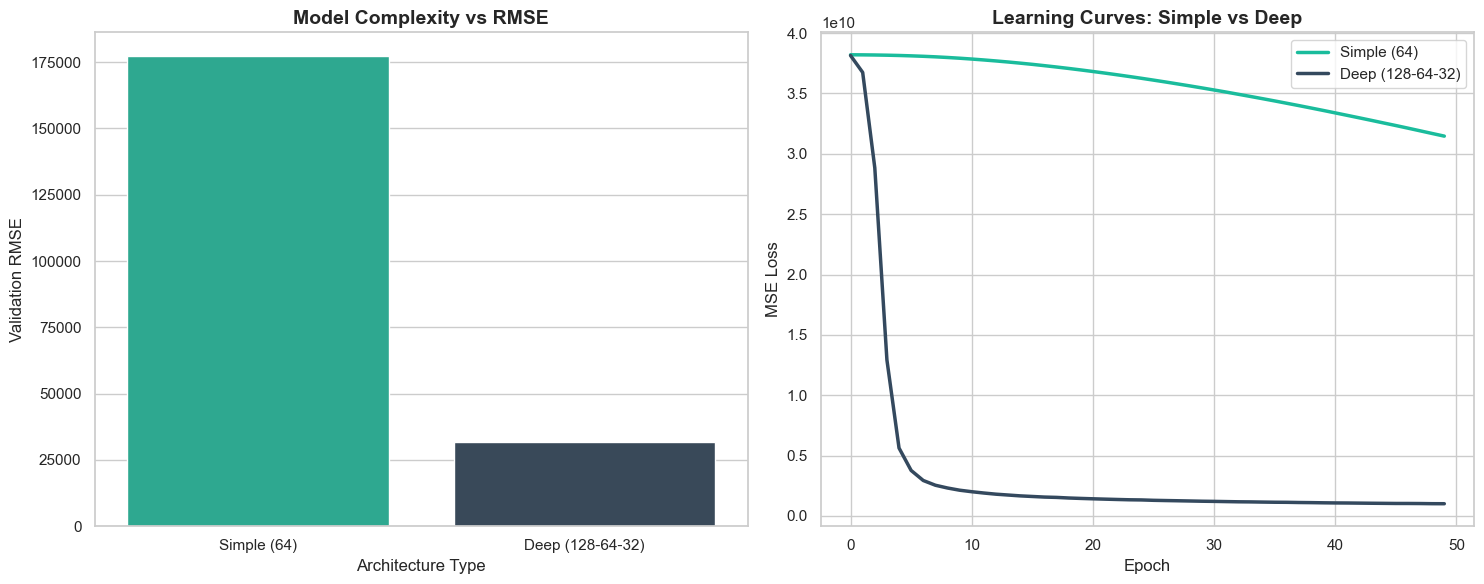

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

# تنظیم ظاهر گرافیکی
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# اسامی کوتاه‌تر برای نمایش در نمودار (اختیاری)
display_names = ["Simple (64)", "Deep (128-64-32)"]
rmse_values = list(arch_results.values())

# ۱. نمودار میله‌ای مقایسه نهایی RMSE
colors = ["#1abc9c", "#34495e"] # سبز کله‌غازی و سربی تیره
sns.barplot(x=display_names, y=rmse_values, hue=display_names, 
            palette=colors, legend=False, ax=ax[0])

ax[0].set_title('Model Complexity vs RMSE', fontsize=14, fontweight='bold')
ax[0].set_ylabel('Validation RMSE')
ax[0].set_xlabel('Architecture Type')

# ۲. نمودار روند یادگیری (Loss) برای هر دو معماری
for (arch_name, history), color, label in zip(arch_histories.items(), colors, display_names):
    ax[1].plot(history.history['val_loss'], 
               label=label, color=color, linewidth=2.5)

ax[1].set_title('Learning Curves: Simple vs Deep', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('MSE Loss')
ax[1].legend()

# بهینه‌سازی فاصله بین نمودارها
plt.tight_layout()
plt.show()


In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Predict on test set
y_pred = model.predict(X_test_scaled).flatten()

# Compute absolute errors
abs_errors = np.abs(y_test - y_pred)

# Create a dataframe for analysis
error_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Absolute_Error': abs_errors
})

# Get top 5 largest errors
top5_errors = error_df.sort_values(by='Absolute_Error', ascending=False).head(5)

print(top5_errors)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
      Actual      Predicted  Absolute_Error
2181  184750  573393.250000   388643.250000
104   267916   11516.226562   256399.773438
433   582933  432186.781250   150746.218750
44    611657  462475.843750   149181.156250
2445  625000  492259.062500   132740.937500


In [79]:
# Assuming X_test is the original unscaled dataframe with same index as X_test_scaled
top5_indices = top5_errors.index

# Display corresponding feature values
top5_features = X_test.loc[top5_indices]

print(top5_features)

      Order        PID  MS SubClass  Lot Frontage  Lot Area  Overall Qual  \
2181   2182  908154205           60         130.0     40094            10   
104     105  533238045           20          57.0     12853             8   
433     434  528110090           60         107.0     13891             9   
44       45  528150070           20         100.0     12919             9   
2445   2446  528320060           60         118.0     35760            10   

      Overall Cond  Year Built  Year Remod/Add  Mas Vnr Area  ...  \
2181             5        2007            2008         762.0  ...   
104              5        2010            2010           0.0  ...   
433              5        2008            2009         424.0  ...   
44               5        2009            2010         760.0  ...   
2445             5        1995            1996        1378.0  ...   

      Sale Type_New  Sale Type_Oth  Sale Type_VWD  Sale Type_WD   \
2181           True          False          False     